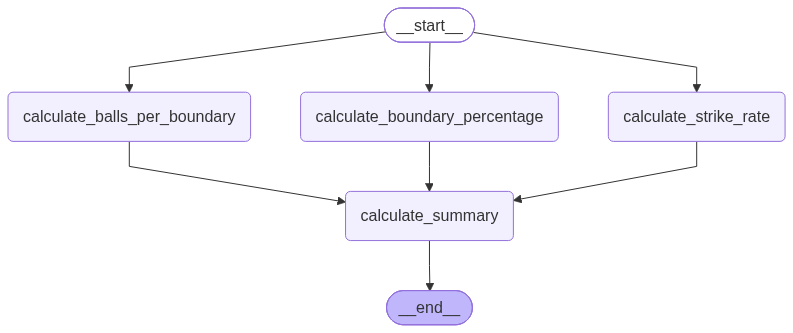

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    balls_per_boundary: float
    boundary_percentage: float
    summary: str


def calcuate_strike_rate(state: BatsmanState):
    sr = (state['runs'] / state['balls']) * 100
    # state['sr'] = sr
    return {'sr': sr}

def calcuate_balls_per_boundary(state: BatsmanState):
    balls_per_boundary = state['balls'] / (state['fours'] + state['sixes'])
    return {'balls_per_boundary': balls_per_boundary}

def calculate_boundary_percentage(state: BatsmanState):
    boundary_percentage = (state['fours'] * 4 + state['sixes'] * 6) / state['runs'] * 100
    return {'boundary_percentage': boundary_percentage}

def calcuate_summary(state: BatsmanState):
    summary = f"Runs: {state['runs']}, \
            Balls: {state['balls']},\
            Fours: {state['fours']},\
            Sixes: {state['sixes']},\
            Strike Rate: {state['sr']:.2f},\
            Balls per Boundary: {state['balls_per_boundary']:.2f},\
            Boundary Percentage: {state['boundary_percentage']:.2f}%"

    return {'summary': summary}

graph = StateGraph(BatsmanState)

# ceating nodes
graph.add_node('calculate_strike_rate', calcuate_strike_rate)
graph.add_node('calculate_balls_per_boundary', calcuate_balls_per_boundary)
graph.add_node('calculate_boundary_percentage', calculate_boundary_percentage)
graph.add_node('calculate_summary', calcuate_summary)

# creating edges
graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_balls_per_boundary')
graph.add_edge(START, 'calculate_boundary_percentage')

graph.add_edge('calculate_strike_rate', 'calculate_summary')
graph.add_edge('calculate_balls_per_boundary', 'calculate_summary')
graph.add_edge('calculate_boundary_percentage', 'calculate_summary')

graph.add_edge('calculate_summary', END)


workflow = graph.compile()
workflow

In [7]:
initial_days = {
    'runs': 50,
    'balls': 30,
    'fours': 4,
    'sixes': 2
}

workflow.invoke(initial_days)

{'runs': 50,
 'balls': 30,
 'fours': 4,
 'sixes': 2,
 'sr': 166.66666666666669,
 'balls_per_boundary': 5.0,
 'boundary_percentage': 56.00000000000001,
 'summary': 'Runs: 50,             Balls: 30,            Fours: 4,            Sixes: 2,            Strike Rate: 166.67,            Balls per Boundary: 5.00,            Boundary Percentage: 56.00%'}